In [ ]:
import pandas as pd
from pygments.lexer import include

from assignment.data_loader import DataLoader
import matplotlib.pyplot as plt
import numpy as np

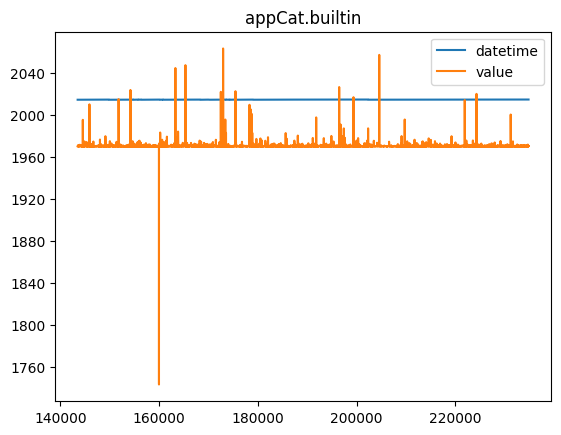

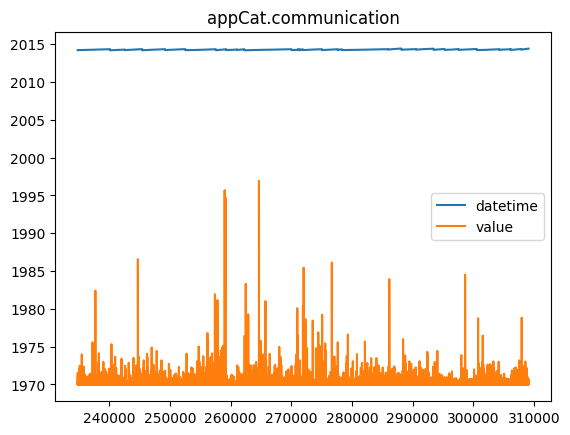

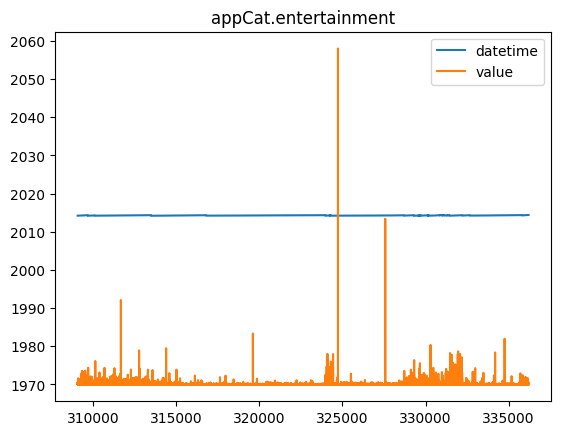

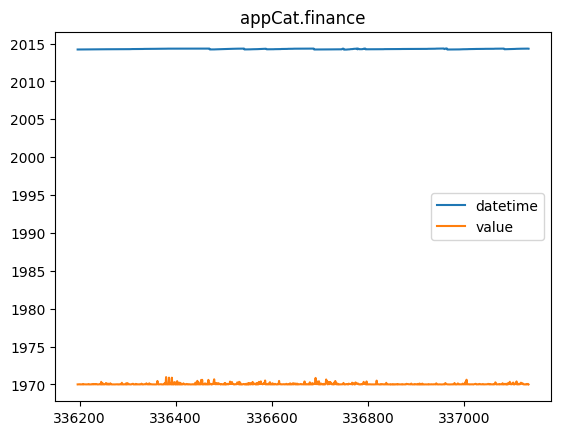

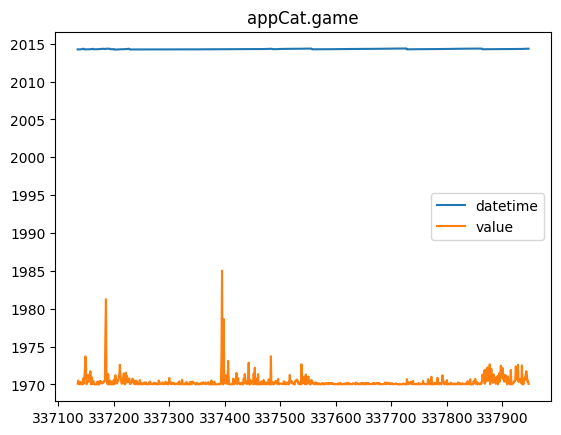

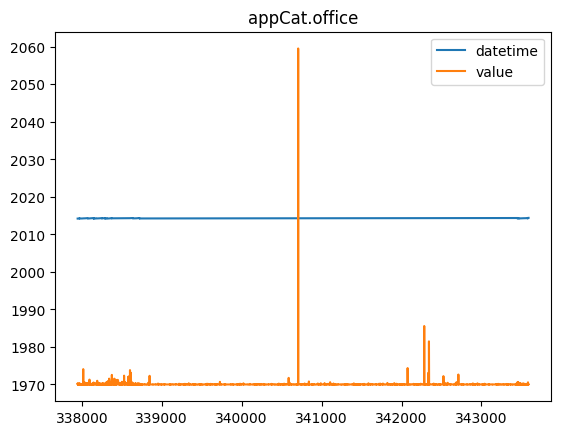

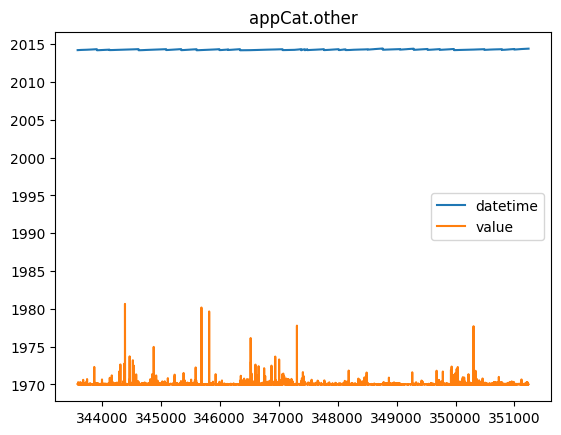

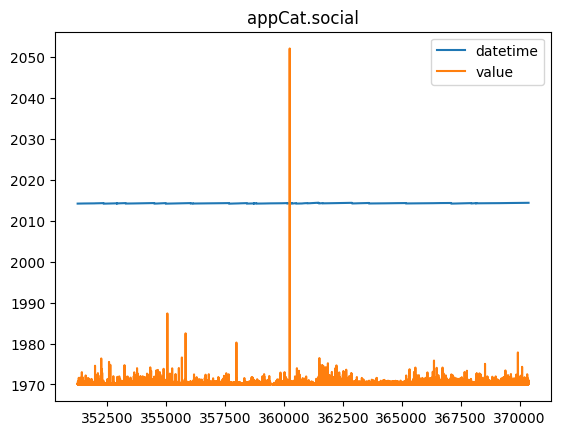

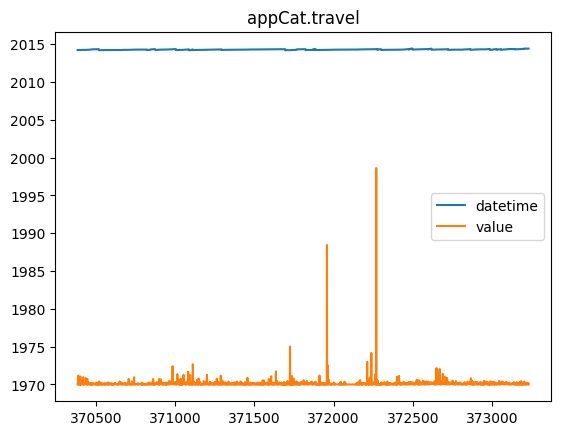

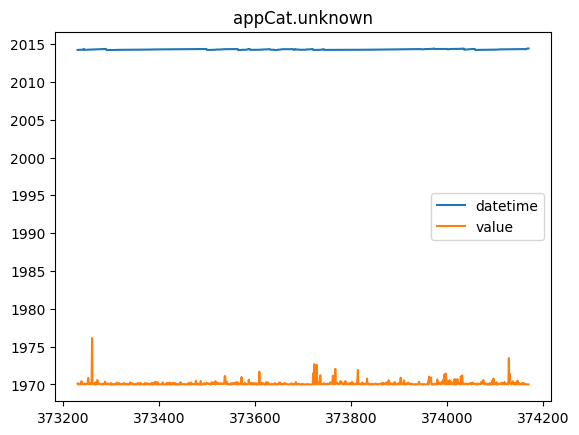

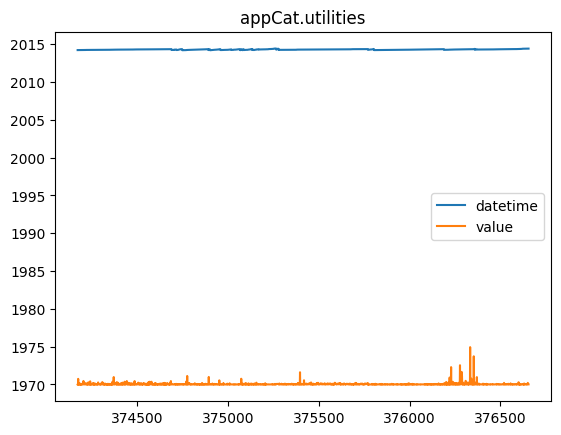

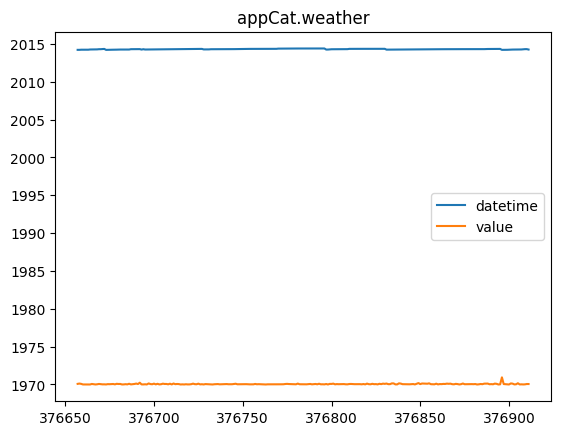

In [225]:
# df = df.set_index('datetime').sort_index()
for variable, sdf in list(df.groupby(["variable"])):
    # print(variable)
    sdf.plot(title=variable[0])

In [ ]:
df.groupby(["variable"]).value.agg(["count", "mean", "median", "max", "min"])
_, (fst, *_) = zip(*df.groupby(["date", "id"]))
fst.value.to_string()


df.variable.unique()
df = df[df.variable.str.startswith("appCat")]
a = .01
clean_and_sum = lambda v: v[(v >= v.quantile(a)) & (v <= v.quantile(1-a))].sum() / 3600
df.groupby(["date", "id"]).value.apply(clean_and_sum).unstack().fillna(0).plot()


series.apply(lambda string: string.startwith("")) #<=>
series.str.startwith("")

KeyError: 'mood'

In [ ]:

df = DataLoader.load_to_df()
# dfx = df.groupby(["id", "date", "variable"]).apply(len)
moods = df[df.variable == "mood"].drop(columns=['variable'])
# moods = df[df.variable == "mood"].value.plot()

df = df[df['date'] == df['date'].unique()[-30]]
df = df[['id', 'datetime', 'value']]
for user, sdf in df.groupby('id'):
    print(sdf)
    plt.plot(sdf.set_index('datetime').sort_index().value, label=user)
# df.groupby('id').apply(lambda sdf: plt.plot(sdf[['datetime', 'value']].set_index('datetime'), label=sdf.id.iloc[0]))
    plt.legend()
    plt.show()
df.pivot_table(columns='id', values='value', index='datetime').plot()
df.set_index(['datetime', 'id'])['value']
print(len(df))
df = df.groupby(["id", 'date']
).apply(lambda x: x.iloc[:10])
print(len(df))
dfx
dfx.unstack()['mood'].to_frame()

### number of users

In [164]:
len(df["id"].head())

5

<Axes: xlabel='date'>

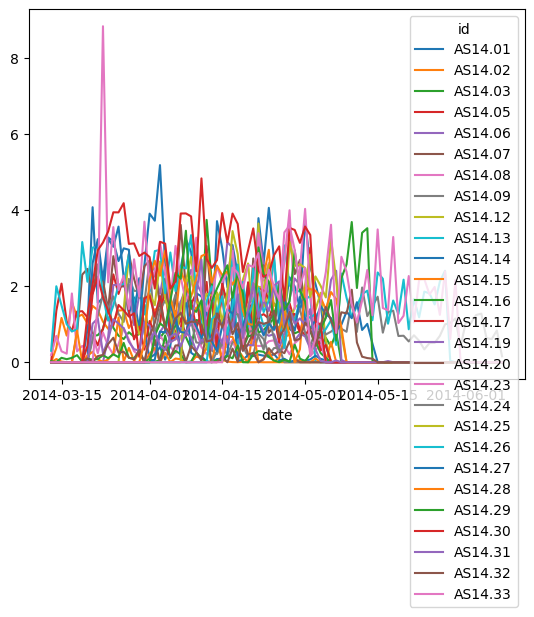

In [224]:
df.datetime.dt
df.varaible.str

class Series:
    def stratwith(self):
        ... #no

class StringMethod:
    def __init__(self, df_or_series):
        assert isinstance(df_or_series, pd.Series)
        assert all(isinstance(value, str) for value in df_or_series)
        ...
    def startswith(self, value):
        return self.df.apply(lambda string: string.stratwith(value))

In [73]:
records_per_user_per_day = df.pivot_table(columns=["variable"], index=["id", "date"], values="value")
# print(records_per_user_per_day.mood.value_counts())

for uid, sdf in list(df.groupby("id")):

    dates_with_mood = sdf.groupby("date").apply(lambda x: len(x[x["variable"] == "mood"])).to_frame("n_mood_records").reset_index()
    records_per_day = sdf.groupby("date").variable.count().to_frame("n_records").reset_index()
    records_per_day.plot(x="date", y="n_records")


    dates_with_mood.plot(x="date", y="n_mood_records")
    print(dates_with_mood.reset_index().head())

records_per_day.join(dates_with_mood)
records_per_user_per_day_with_moods = records_per_user_per_day[records_per_user_per_day['mood'].notna()]
print(records_per_user_per_day_with_moods)

/var/folders/ck/63g66f6935lgl8mlzt8bpztr0000gn/T/ipykernel_97462/767777004.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dates_with_mood = sdf.groupby("date").apply(lambda x: len(x[x["variable"] == "mood"])).to_frame("n_mood_records").reset_index()
/var/folders/ck/63g66f6935lgl8mlzt8bpztr0000gn/T/ipykernel_97462/767777004.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dates_with_mood = sdf.groupb

<Axes: xlabel='date'>

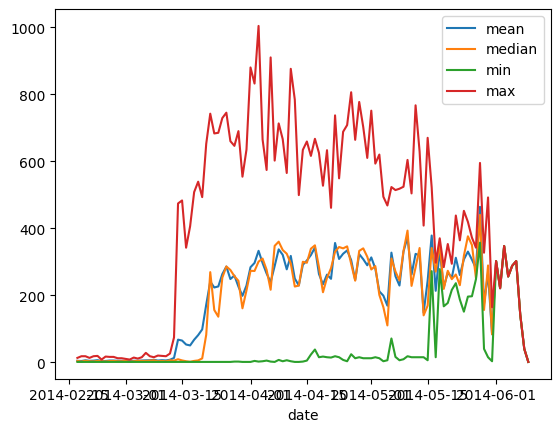

In [54]:
records_per_user_per_day = df.groupby(["id", "date"]).variable.count().to_frame().pivot_table(columns="id", index="date", values="variable")
records_per_user_per_day.agg(["mean", "median", "min", "max"], axis=1).plot()


In [56]:

for uid, sdf in list(df.groupby("id"))[:1]:
    dates_with_mood = sdf.groupby("date").apply(lambda x: len(x[x["variable"] == "mood"])).to_frame("n_mood_records")
    records_per_day = sdf.groupby("date").variable.count().to_frame("n_records")

records_per_day.join(dates_with_mood)

/var/folders/ck/63g66f6935lgl8mlzt8bpztr0000gn/T/ipykernel_97462/4155273757.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dates_with_mood = sdf.groupby("date").apply(lambda x: len(x[x["variable"] == "mood"])).to_frame("n_mood_records")


,n_records,n_mood_records
date,,
2014-02-17,2,0
2014-02-18,1,0
2014-02-19,9,0
2014-02-20,5,0
2014-02-21,1,0
...,...,...
2014-05-01,751,5
2014-05-02,481,5
2014-05-03,304,5


<Axes: xlabel='date'>

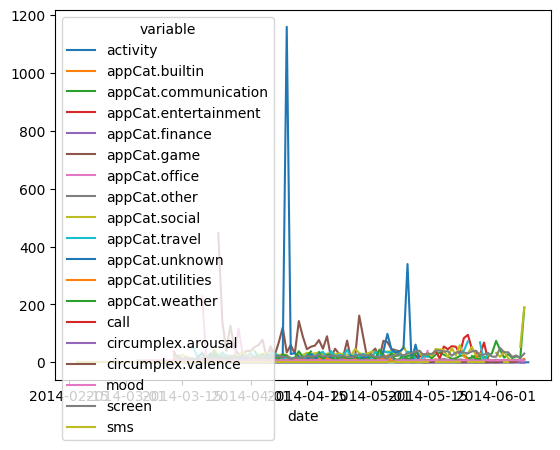

In [14]:
df["value"] = df["value"].astype(float)
df.groupby(["date", "variable"]).value.median().unstack().plot()

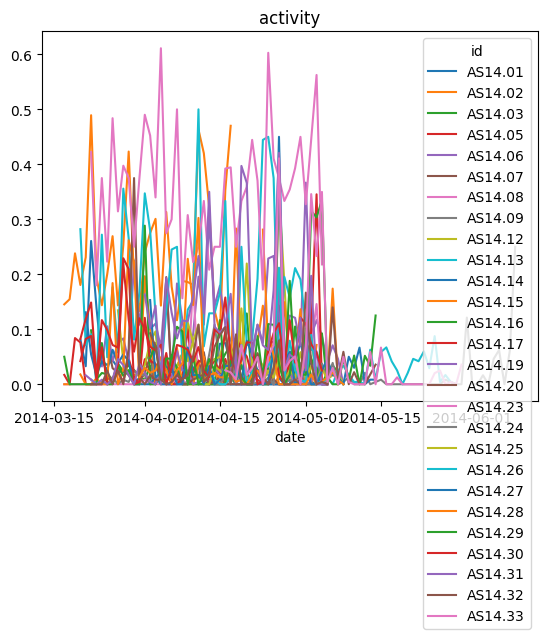

In [130]:
for factor, sdf in list(df.groupby("variable"))[:1]:
    sdf.pivot_table(columns="id", index="date", values="value")
    sdf_var = sdf.groupby(["date", "id"]).value.median().unstack()
    sdf_var.plot(title=factor)


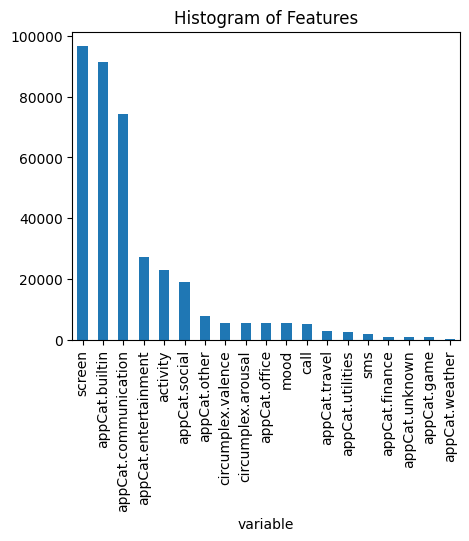

In [111]:
df.variable.value_counts().plot.bar(title="Histogram of Features", legend=None,figsize=(5,4));

In [153]:
for factor, sdf in list(df.groupby("variable"))[:1]:
    # sdf.groupby(["date", "id"]).value.median().unstack().plot.bar(title=factor, legend=None,figsize=(10,7))
    # sdf.groupby(["date", "id"]).value.median().unstack()
    sdf = sdf.pivot_table(columns="id", index="date", values="value").reset_index()
sdf

id,date,AS14.01,AS14.02,AS14.03,AS14.05,AS14.06,AS14.07,AS14.08,AS14.09,AS14.12,...,AS14.24,AS14.25,AS14.26,AS14.27,AS14.28,AS14.29,AS14.30,AS14.31,AS14.32,AS14.33
0,2014-03-17,NaN,0.168068,NaN,0.083371,NaN,NaN,0.005556,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-03-18,NaN,0.219484,NaN,0.113196,NaN,NaN,0.028491,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-03-19,NaN,0.315632,NaN,0.133691,NaN,NaN,0.063017,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-03-20,0.081548,0.239025,NaN,0.118457,NaN,NaN,0.057524,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.082270,NaN,NaN,NaN
4,2014-03-21,0.134050,0.289628,NaN,0.050198,NaN,NaN,0.008942,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.212259,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,2014-06-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.152343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
81,2014-06-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.189476,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
82,2014-06-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.081893,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
83,2014-06-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.079510,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
